Propagating GEO for 30 days...

  MISSION ANALYSIS: PARAMETERS VARIATION AFTER 30 DAYS (GEO)
  Model: 10x10 Gravity, SRP, Luni-Solar Third Body (NO DRAG)
1. SEMI-MAJOR AXIS (a)
   Initial: 42164.140 km
   Final:   42160.948 km
   Delta:   -3192.25 meters (-3.192248 km) (Oscillation induced by tesseral harmonics, East-West drift)
--------------------------------------------------------------------
2. ECCENTRICITY (e)
   Initial: 0.000100
   Final:   0.000069
   Delta:   -0.000031 (Drift caused by Solar Radiation Pressure)
--------------------------------------------------------------------
3. INCLINATION (i)
   Initial: 0.01000 deg
   Final:   0.06885 deg
   Delta:   0.05885 deg (North-South drift caused by Luni-Solar)
--------------------------------------------------------------------
4. RAAN (Ω)
   Initial: 0.000 deg
   Final:   89.834 deg (Standard Modulo 360)
   Delta:   89.834 deg
--------------------------------------------------------------------
5. ARGUMENT OF PERIGEE (ω)
   In

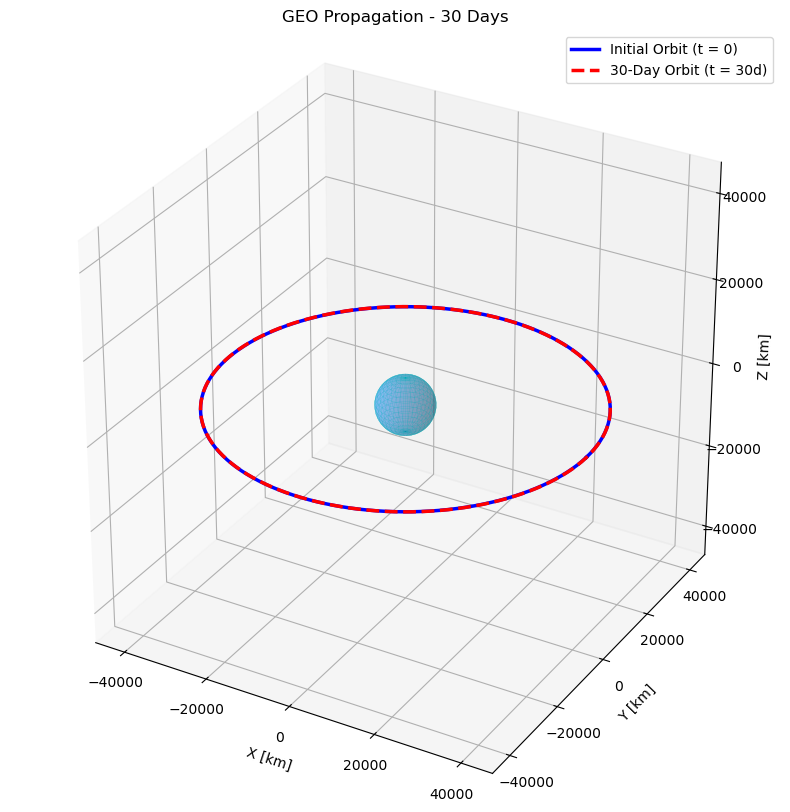

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from orekit import JArray_double

# ==========================================
# 1. OREKIT ENVIRONMENT INITIALIZATION
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants, IERSConventions
from org.orekit.propagation.numerical import NumericalPropagator
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel, ThirdBodyAttraction
from org.orekit.bodies import CelestialBodyFactory, OneAxisEllipsoid
from org.orekit.forces.radiation import SolarRadiationPressure, IsotropicRadiationSingleCoefficient

# ==========================================
# 2. TIME AND FRAMES DEFINITION
# ==========================================
utc = TimeScalesFactory.getUTC()
initial_date = AbsoluteDate(2026, 8, 4, 12, 0, 0.0, utc)

inertial_frame = FramesFactory.getEME2000()
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True)
earth_shape = OneAxisEllipsoid(Constants.WGS84_EARTH_EQUATORIAL_RADIUS, 
                               Constants.WGS84_EARTH_FLATTENING, 
                               earth_frame)
mu = Constants.WGS84_EARTH_MU

# ==========================================
# 3. ORBIT CREATION (GEO)
# ==========================================
# At 42164 km the period is one sidereal day (~23h 56m)
a = 42164140.0  
e = 0.0001      # Quasi-circular (avoids mathematical singularities)
i = math.radians(0.01) # Quasi-equatorial (avoids singularities)
omega = math.radians(0.0)
raan = math.radians(0.0)
lM = math.radians(0.0)

initial_orbit = KeplerianOrbit(a, e, i, omega, raan, lM, PositionAngleType.MEAN, inertial_frame, initial_date, mu)
initial_state = SpacecraftState(initial_orbit, 2500.0) # Typical mass of a telecommunication satellite

# ==========================================
# 4. PROPAGATOR CONFIGURATION
# ==========================================
min_step = 0.001
max_step = 1000.0 # Larger maximum steps because GEO dynamics are slow
position_tolerance = 10.0 
tolerances = NumericalPropagator.tolerances(position_tolerance, initial_orbit, initial_orbit.getType())
abs_tolerance = JArray_double.cast_(tolerances[0])
rel_tolerance = JArray_double.cast_(tolerances[1])

integrator = DormandPrince853Integrator(min_step, max_step, abs_tolerance, rel_tolerance)
propagator = NumericalPropagator(integrator)
propagator.setInitialState(initial_state)

ephemeris_generator = propagator.getEphemerisGenerator()

# ==========================================
# 5. ADDING PERTURBATIONS 
# ==========================================
# EGM96 Gravity (10x10 Harmonics) 
gravity_provider = GravityFieldFactory.getNormalizedProvider(10, 10)
propagator.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, gravity_provider))

# Third Body (Sun and Moon - Dominant in GEO for inclination)
sun = CelestialBodyFactory.getSun()
moon = CelestialBodyFactory.getMoon()
propagator.addForceModel(ThirdBodyAttraction(sun))
propagator.addForceModel(ThirdBodyAttraction(moon))

# Solar Radiation Pressure (SRP - Dominant in GEO for eccentricity)
propagator.addForceModel(SolarRadiationPressure(sun, earth_shape, IsotropicRadiationSingleCoefficient(35.0, 1.2))) # Very large exposed area (solar panels)

# ==========================================
# 6. PROPAGATION (30 DAYS)
# ==========================================
days = 30.0
duration = days * 24.0 * 3600.0  
final_date = initial_date.shiftedBy(duration)

print(f"Propagating GEO for {int(days)} days...")
final_state = propagator.propagate(final_date)

ephemeris = ephemeris_generator.getGeneratedEphemeris()
orbit_30d = KeplerianOrbit(final_state.getOrbit())

# ==========================================
# 7. MISSION ANALYSIS REPORT
# ==========================================
a_fin = orbit_30d.getA()
e_fin = orbit_30d.getE()
i_fin = math.degrees(orbit_30d.getI())

raan_fin_raw = math.degrees(orbit_30d.getRightAscensionOfAscendingNode())
omega_fin_raw = math.degrees(orbit_30d.getPerigeeArgument())

raan_fin_mod = raan_fin_raw % 360.0
omega_fin_mod = omega_fin_raw % 360.0

# Calculation of normalized delta (shortest angular path relative to initial zero)
delta_raan = (raan_fin_raw - math.degrees(raan) + 180.0) % 360.0 - 180.0
delta_omega = (omega_fin_raw - math.degrees(omega) + 180.0) % 360.0 - 180.0

print("\n====================================================================")
print(f"  MISSION ANALYSIS: PARAMETERS VARIATION AFTER {int(days)} DAYS (GEO)")
print("  Model: 10x10 Gravity, SRP, Luni-Solar Third Body (NO DRAG)")
print("====================================================================")
print(f"1. SEMI-MAJOR AXIS (a)")
print(f"   Initial: {a/1000:.3f} km")
print(f"   Final:   {a_fin/1000:.3f} km")
print(f"   Delta:   {(a_fin - a):.2f} meters ({(a_fin - a)/1000:.6f} km) (Oscillation induced by tesseral harmonics, East-West drift)")
print("--------------------------------------------------------------------")
print(f"2. ECCENTRICITY (e)")
print(f"   Initial: {e:.6f}")
print(f"   Final:   {e_fin:.6f}")
print(f"   Delta:   {e_fin - e:.6f} (Drift caused by Solar Radiation Pressure)")
print("--------------------------------------------------------------------")
print(f"3. INCLINATION (i)")
print(f"   Initial: {math.degrees(i):.5f} deg")
print(f"   Final:   {i_fin:.5f} deg")
print(f"   Delta:   {i_fin - math.degrees(i):.5f} deg (North-South drift caused by Luni-Solar)")
print("--------------------------------------------------------------------")
print(f"4. RAAN (\u03A9)")
print(f"   Initial: {math.degrees(raan):.3f} deg")
print(f"   Final:   {raan_fin_mod:.3f} deg (Standard Modulo 360)")
print(f"   Delta:   {delta_raan:.3f} deg")
print("--------------------------------------------------------------------")
print(f"5. ARGUMENT OF PERIGEE (\u03C9)")
print(f"   Initial: {math.degrees(omega):.3f} deg")
print(f"   Final:   {omega_fin_mod:.3f} deg (Standard Modulo 360)")
print(f"   Delta:   {delta_omega:.3f} deg")
print("====================================================================\n")

# ==========================================
# 8. 3D VISUALIZATION
# ==========================================
print("Generating 3D plot...")
orbital_period = 86164.0  # One sidereal day in seconds

def extract_orbit(start_time, end_time):
    times = np.linspace(start_time, end_time, 150)
    x, y, z = [], [], []
    for t in times:
        current_date = initial_date.shiftedBy(float(t))
        pos = ephemeris.propagate(current_date).getPVCoordinates().getPosition()
        x.append(pos.getX() / 1000.0)
        y.append(pos.getY() / 1000.0)
        z.append(pos.getZ() / 1000.0)
    return x, y, z

x0, y0, z0 = extract_orbit(0, orbital_period)                                   
x30, y30, z30 = extract_orbit(duration - orbital_period, duration)              

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
R_E_km = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0
x_earth = R_E_km * np.cos(u) * np.sin(v)
y_earth = R_E_km * np.sin(u) * np.sin(v)
z_earth = R_E_km * np.cos(v)
ax.plot_surface(x_earth, y_earth, z_earth, color='dodgerblue', alpha=0.3, edgecolor='c', linewidth=0.2)

ax.plot(x0, y0, z0, color='blue', linewidth=2.5, label='Initial Orbit (t = 0)')
ax.plot(x30, y30, z30, color='red', linewidth=2.5, linestyle='dashed', label='30-Day Orbit (t = 30d)')

# Graph limits set to contain GEO (~42000 km)
lim = a / 1000.0 + 5000 
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_box_aspect([1,1,1]) 

ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('GEO Propagation - 30 Days')
ax.legend(loc='upper right')

plt.show()